In [1]:
import dask
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmcrameri as cm
import os
import matplotlib.gridspec as gridspec  
import warnings
from cmcrameri import cm
import babet as bb

warnings.filterwarnings("ignore", category=FutureWarning)
dask.config.set(**{'array.slicing.split_large_chunks': True})

In [2]:
base_dir = '/gf5/predict/AWH019_ERMIS_ATMICP/test_ATMICP/INTEGRATIONS/GLO100/{}/{}/'

In [3]:
def preproc_leadtime(ds):
    """
    bb.data.Data.preproc_ds_v2 + convert the time axis to lead time
    (hours since initialisation).

    Doing the conversion here, per file, keeps time 1-dimensional. If it is done
    after combining, ds.time - ds.inidate broadcasts to (inidate, time) and the
    2D 'time' coord can no longer be indexed/selected.
    """
    ds = bb.data.Data.preproc_ds_v2(ds)

    inidate = ds.inidate.values[0]
    ds = ds.assign_coords(time=(ds.time - inidate) / np.timedelta64(1, 'h'))
    ds.time.attrs = {'long_name': 'lead time', 'units': 'hours since initialisation'}

    return ds


def load_pf_cf(expver):

    cf = xr.open_mfdataset(base_dir.format('pl', 'cf') + f'/{expver}*.nc', 
                           preprocess=preproc_leadtime, 
                           combine='by_coords', parallel=True)

    pf = xr.open_mfdataset(base_dir.format('pl', 'pf') + f'/{expver}*.nc', 
                           preprocess=preproc_leadtime, 
                           combine='by_coords', parallel=True)

    # join='outer' keeps cf (number=0) and pf (number=1..10) as one ensemble
    ds = xr.merge([cf, pf], compat='override', join='outer')

    return ds


In [4]:
def plot_maps(da, col, proj=ccrs.Robinson(), col_wrap=4, **kwargs):
    """
    Facet map plot with coastlines.

    Longitudes are shifted from 0..359 to -180..180 first, otherwise half the
    field is drawn outside the map and misses the coastlines.
    """
    da = da.assign_coords(longitude=(((da.longitude + 180) % 360) - 180)).sortby('longitude')

    p = da.plot(col=col, col_wrap=col_wrap,
                transform=ccrs.PlateCarree(),  # the data itself is on a regular lat/lon grid
                subplot_kws={'projection': proj},
                **kwargs)

    for ax in p.axes.flat:
        ax.coastlines(resolution='110m', linewidth=0.5, color='k')
        ax.set_global()

    return p


In [5]:
# load current climate 
curr = load_pf_cf('b2ut')

# load iterated future climate
incr = load_pf_cf('b2vk')

Text(0.5, 1.0, 'incr - curr, T at 1000 hPa')

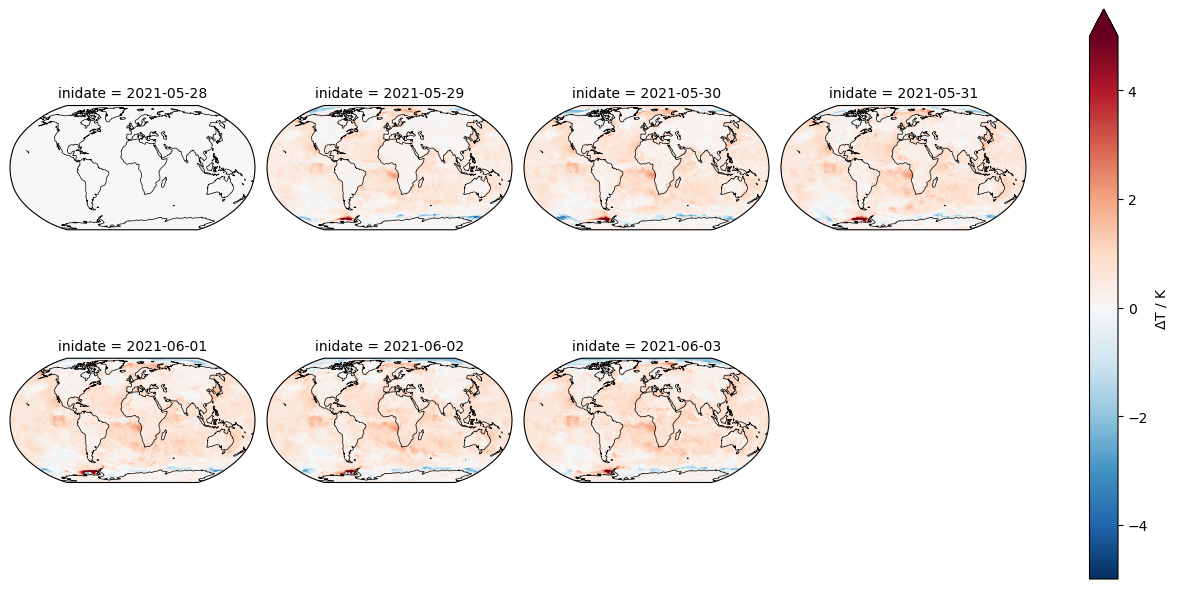

In [6]:
# plot difference at 1000hPa at initialisation for all inidates

diff = (incr - curr).t.sel(level=1000, time=0).mean('number')

plot_maps(diff, col='inidate', cmap='RdBu_r', vmin=-5, vmax=5,
          cbar_kwargs={'label': r'$\Delta$T / K'})

plt.title('incr - curr, T at 1000 hPa')


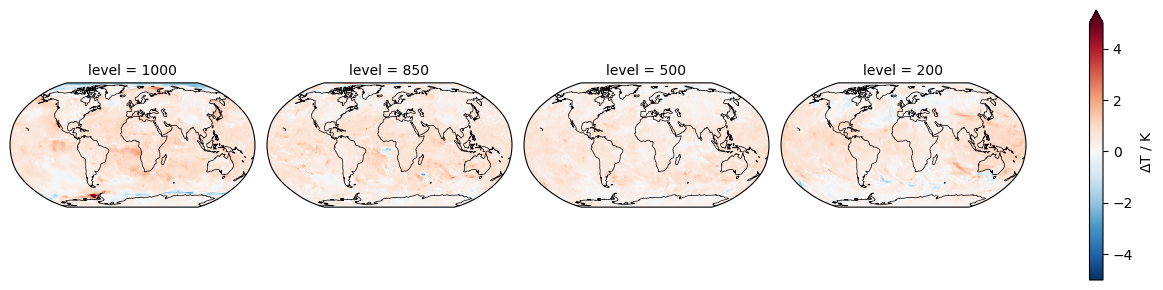

In [7]:
# plot difference for June 3rd inidate at all pressure levels
diff = (incr - curr).t.sel(inidate='2021-06-03', time=0).mean('number')

plot_maps(diff, col='level', cmap='RdBu_r', vmin=-5, vmax=5,
          cbar_kwargs={'label': r'$\Delta$T / K'})
# plt.title('incr - curr, T at 2021-06-03')
